# Credit Default Risk Project

In [1]:
import os
from pathlib import Path
import time
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    RandomizedSearchCV,
    cross_val_predict
)
from scipy.stats import randint, uniform
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, RobustScaler, PowerTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    brier_score_loss,
    precision_recall_curve,
    roc_curve,
    ConfusionMatrixDisplay
)

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)
warnings.filterwarnings("ignore")

RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)

In [2]:
TARGET = "default payment next month"
POSITIVE_CLASS = 1
COST_FN, COST_FP = 5, 1
PRIMARY_METRIC = "Average Precision (AUC PR)"
print({"target": TARGET, "positive_class": POSITIVE_CLASS, "FN_cost": COST_FN, "FP_cost": COST_FP, "primary_metric": PRIMARY_METRIC})

{'target': 'default payment next month', 'positive_class': 1, 'FN_cost': 5, 'FP_cost': 1, 'primary_metric': 'Average Precision (AUC PR)'}


## 2. Data loading and initial inspection

In [3]:
DATA_DIR = Path("data")
XLS_PATH = DATA_DIR / "default of credit card clients.xls"
PROCESSED_PATH = DATA_DIR / "credit_default_processed.csv"

try:
    # Preferred: untouched UCI raw file. Requires xlrd for .xls files.
    df = pd.read_excel(XLS_PATH, header=1)
    loaded_from = XLS_PATH
except (ImportError, ModuleNotFoundError, ValueError, FileNotFoundError):
    # Reproducible fallback using the supplied processed copy; the raw file is still kept untouched in data/.
    df = pd.read_csv(PROCESSED_PATH)
    loaded_from = PROCESSED_PATH

print("Loaded from:", loaded_from)
print("Shape:", df.shape)
display(df.head())

Loaded from: data\default of credit card clients.xls
Shape: (30000, 25)


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,...,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,...,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,...,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,...,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,...,20940,19146,19131,2000,36681,10000,9000,689,679,0


In [4]:
print(df.columns.tolist())

['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


In [5]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nMissing values:")
print(df.isnull().sum().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

print("\nTarget distribution:")
print(df["default payment next month"].value_counts())

print("\nTarget percentage:")
print(df["default payment next month"].value_counts(normalize=True) * 100)

Rows: 30000
Columns: 25

Missing values:
0

Duplicate rows:
0

Target distribution:
default payment next month
0    23364
1     6636
Name: count, dtype: int64

Target percentage:
default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


In [6]:
# Delete ID column

X = df.drop(columns=["ID", "default payment next month"])
y = df["default payment next month"]

## 3. Data dictionary and variable types

In [7]:
data_dictionary = pd.DataFrame({
    "Feature": [
        "LIMIT_BAL",
        "SEX",
        "EDUCATION",
        "MARRIAGE",
        "AGE",
        "PAY_0",
        "PAY_2",
        "PAY_3",
        "PAY_4",
        "PAY_5",
        "PAY_6",
        "BILL_AMT1",
        "BILL_AMT2",
        "BILL_AMT3",
        "BILL_AMT4",
        "BILL_AMT5",
        "BILL_AMT6",
        "PAY_AMT1",
        "PAY_AMT2",
        "PAY_AMT3",
        "PAY_AMT4",
        "PAY_AMT5",
        "PAY_AMT6"
    ],
    
    "Type": [
        "Numeric",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numeric",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Categorical",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric",
        "Numeric"
    ],

   "نام مفهومی": [
           "سقف اعتبار",
           "جنسیت",
           "تحصیلات",
           "وضعیت تأهل",
           "سن",
           "وضعیت بازپرداخت 0",
           "وضعیت بازپرداخت 2",
           "وضعیت بازپرداخت 3",
           "وضعیت بازپرداخت 4",
           "وضعیت بازپرداخت 5",
           "وضعیت بازپرداخت 6",
           "مبلغ صورتحساب 1",
           "مبلغ صورتحساب 2",
           "مبلغ صورتحساب 3",
           "مبلغ صورتحساب 4",
           "مبلغ صورتحساب 5",
           "مبلغ صورتحساب 6",
           "مبلغ پرداختی 1",
           "مبلغ پرداختی 2",
           "مبلغ پرداختی 3",
           "مبلغ پرداختی 4",
           "مبلغ پرداختی 5",
           "مبلغ پرداختی 6"
       ],
       
    "توضیح": [
               "مبلغ اعتبار",
               "مرد = 1 , زن = 2",
               "عالی = 1 , دانشگاه = 2 , دبیرستان = 3 , سایر = 4",
               "متاهل = 1 , مجرد = 2 , سایر = 3",
               "سن",
               "بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پرداخت = 0 و تاخیر 1 ماه = 1 و تاخیر 2 ماه = 2 و",
               "بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پرداخت = 0 و تاخیر 1 ماه = 1 و تاخیر 2 ماه = 2 و",
               "بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پرداخت = 0 و تاخیر 1 ماه = 1 و تاخیر 2 ماه = 2 و",
               "بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پرداخت = 0 و تاخیر 1 ماه = 1 و تاخیر 2 ماه = 2 و",
               "بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پرداخت = 0 و تاخیر 1 ماه = 1 و تاخیر 2 ماه = 2 و",
               "بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پرداخت = 0 و تاخیر 1 ماه = 1 و تاخیر 2 ماه = 2 و",
               "مبلغ صورتحساب ماه 1",
               "مبلغ صورتحساب ماه 2",
               "مبلغ صورتحساب ماه 3",
               "مبلغ صورتحساب ماه 4",
               "مبلغ صورتحساب ماه 5",
               "مبلغ صورتحساب ماه 6",
               "مبلغ پرداختی ماه 1",
               "مبلغ پرداختی ماه 2",
               "مبلغ پرداختی ماه 3",
               "مبلغ پرداختی ماه 4",
               "مبلغ پرداختی ماه 5",
               "مبلغ پرداختی ماه 6"
           ]
})

display(data_dictionary)

,Feature,Type,نام مفهومی,توضیح
0,LIMIT_BAL,Numeric,سقف اعتبار,مبلغ اعتبار
1,SEX,Categorical,جنسیت,"مرد = 1 , زن = 2"
2,EDUCATION,Categorical,تحصیلات,"عالی = 1 , دانشگاه = 2 , دبیرستان = 3 , سایر = 4"
3,MARRIAGE,Categorical,وضعیت تأهل,"متاهل = 1 , مجرد = 2 , سایر = 3"
4,AGE,Numeric,سن,سن
5,PAY_0,Categorical,وضعیت بازپرداخت 0,بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پردا...
6,PAY_2,Categorical,وضعیت بازپرداخت 2,بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پردا...
7,PAY_3,Categorical,وضعیت بازپرداخت 3,بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پردا...
8,PAY_4,Categorical,وضعیت بازپرداخت 4,بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پردا...
9,PAY_5,Categorical,وضعیت بازپرداخت 5,بدون مصرف = 2- و پرداخت کامل = 1- و حداقل پردا...


In [8]:
CAT = ['SEX','EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
NUM = ['LIMIT_BAL','AGE'] + [f'BILL_AMT{i}' for i in range(1,7)] + [f'PAY_AMT{i}' for i in range(1,7)]
print("Categorical variables:", CAT)
print("Numeric variables:", NUM)

Categorical variables: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Numeric variables: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']


In [9]:
categorical_features = [
    "SEX",
    "EDUCATION",
    "MARRIAGE",
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]

numeric_features = [
    "LIMIT_BAL",
    "AGE",
    "BILL_AMT1",
    "BILL_AMT2",
    "BILL_AMT3",
    "BILL_AMT4",
    "BILL_AMT5",
    "BILL_AMT6",
    "PAY_AMT1",
    "PAY_AMT2",
    "PAY_AMT3",
    "PAY_AMT4",
    "PAY_AMT5",
    "PAY_AMT6"
]

In [10]:
for col in categorical_features:
    print(f"\n{col}")
    print(sorted(df[col].dropna().unique().tolist()))


SEX
[1, 2]

EDUCATION
[0, 1, 2, 3, 4, 5, 6]

MARRIAGE
[0, 1, 2, 3]

PAY_0
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_2
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_3
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_4
[-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8]

PAY_5
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]

PAY_6
[-2, -1, 0, 2, 3, 4, 5, 6, 7, 8]


## 4. Descriptive and visual analysis

In [11]:
bill_cols=[f'BILL_AMT{i}' for i in range(1,7)]
pay_amt_cols=[f'PAY_AMT{i}' for i in range(1,7)]
pay_cols=[f'PAY_{x}' for x in ['0','2','3','4','5','6']]

stat_cols=['LIMIT_BAL','AGE']+bill_cols+pay_amt_cols
stats=[]
for group,mask in [('All',np.ones(len(df),dtype=bool)),('No Default',y.eq(0)),('Default',y.eq(1))]:
    d=df.loc[mask,stat_cols]
    for col in stat_cols:
        s=d[col]
        stats.append([group,col,s.mean(),s.median(),s.std(),s.min(),s.quantile(.25),s.quantile(.5),s.quantile(.75),s.quantile(.9),s.quantile(.95),s.max()])
stats_df=pd.DataFrame(stats,columns=['group','variable','mean','median','std','min','q25','q50','q75','q90','q95','max'])
display(stats_df[stats_df.group=="All"].round(2))

,group,variable,mean,median,std,min,q25,q50,q75,q90,q95,max
0,All,LIMIT_BAL,167484.32,140000.0,129747.66,10000,50000.00,140000.0,240000.00,360000.0,430000.00,1000000
1,All,AGE,35.49,34.0,9.22,21,28.00,34.0,41.00,49.0,53.00,79
2,All,BILL_AMT1,51223.33,22381.5,73635.86,-165580,3558.75,22381.5,67091.00,142133.7,201203.05,964511
3,All,BILL_AMT2,49179.08,21200.0,71173.77,-69777,2984.75,21200.0,64006.25,136905.5,194792.20,983931
4,All,BILL_AMT3,47013.15,20088.5,69349.39,-157264,2666.25,20088.5,60164.75,132051.3,187821.05,1664089
5,All,BILL_AMT4,43262.95,19052.0,64332.86,-170000,2326.75,19052.0,54506.00,122418.7,174333.35,891586
6,All,BILL_AMT5,40311.40,18104.5,60797.16,-81334,1763.00,18104.5,50190.50,115883.0,165794.30,927171
7,All,BILL_AMT6,38871.76,17071.0,59554.11,-339603,1256.00,17071.0,49198.25,112110.4,161912.00,961664
8,All,PAY_AMT1,5663.58,2100.0,16563.28,0,1000.00,2100.0,5006.00,10300.0,18428.20,873552
9,All,PAY_AMT2,5921.16,2009.0,23040.87,0,833.00,2009.0,5000.00,10401.1,19004.35,1684259


In [12]:
# Descriptive statistics required by the brief. These are descriptive only; model fitting uses Train/Validation/Test below.
bill_cols_stats=[f'BILL_AMT{i}' for i in range(1,7)]
pay_amt_cols_stats=[f'PAY_AMT{i}' for i in range(1,7)]
stat_groups = {'LIMIT_BAL':['LIMIT_BAL'], 'AGE':['AGE'], 'AMT_BILL':bill_cols_stats, 'AMT_PAY':pay_amt_cols_stats}
stat_rows=[]
for group, cols in stat_groups.items():
    values=df[cols].stack()
    stat_rows.append({'group':group,'mean':values.mean(),'median':values.median(),'std':values.std(),'min':values.min(),'q25':values.quantile(.25),'q50':values.quantile(.50),'q75':values.quantile(.75),'q90':values.quantile(.90),'q95':values.quantile(.95),'max':values.max()})
descriptive_stats=pd.DataFrame(stat_rows)
display(descriptive_stats)


,group,mean,median,std,min,q25,q50,q75,q90,q95,max
0,LIMIT_BAL,167484.322667,140000.0,129747.661567,10000,50000.0,140000.0,240000.0,360000.0,430000.00,1000000
1,AGE,35.485500,34.0,9.217904,21,28.0,34.0,41.0,49.0,53.00,79
2,AMT_BILL,44976.945200,19270.0,66834.427826,-339603,2400.0,19270.0,57417.0,127788.2,181532.50,1664089
3,AMT_PAY,5275.232094,1900.0,17846.903147,0,390.0,1900.0,4592.0,10000.0,17549.15,1684259


## 5. Feature engineering and locked Train / Validation / Test split

In [13]:
# Feature engineering uses only predictors available before the target; no target-derived feature is created.
pay_cols = ['PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']
bill_cols = ['BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6']
pay_amt_cols = ['PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6']

df['PAY_MAX_DELAY'] = df[pay_cols].max(axis=1)
df['TOTAL_BILL_6M'] = df[bill_cols].sum(axis=1)
df['TOTAL_PAY_6M'] = df[pay_amt_cols].sum(axis=1)
df['PAYMENT_TO_BILL_RATIO_6M'] = df['TOTAL_PAY_6M'] / (df['TOTAL_BILL_6M'].abs() + 1)
df['BILL_TO_LIMIT_RATIO'] = df['BILL_AMT1'] / (df['LIMIT_BAL'].abs() + 1)

engineered_numeric = ['PAY_MAX_DELAY','TOTAL_BILL_6M','TOTAL_PAY_6M','PAYMENT_TO_BILL_RATIO_6M','BILL_TO_LIMIT_RATIO']
base_numeric = ['LIMIT_BAL','AGE'] + bill_cols + pay_amt_cols
categorical_cols = ['SEX','EDUCATION','MARRIAGE'] + pay_cols
numeric_cols = base_numeric + engineered_numeric
model_features = numeric_cols + categorical_cols

X = df[model_features].copy()
y = df[TARGET].astype(int).copy()

# REQUIRED PROJECT SPLIT: 80% Train pool / 20% untouched Test.
# The internal validation set below is carved out only from the 80% Train pool;
# it is not a third top-level dataset and Test remains locked until final evaluation.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
X_fit, X_val, y_fit, y_val = train_test_split(
    X_train, y_train, test_size=0.25, stratify=y_train, random_state=RANDOM_STATE
)

print(f'Total: {len(X):,}')
print(f'Train pool: {len(X_train):,} ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test (locked): {len(X_test):,} ({len(X_test)/len(X)*100:.1f}%)')
print(f'Internal fit subset: {len(X_fit):,} ({len(X_fit)/len(X)*100:.1f}% overall)')
print(f'Internal validation subset: {len(X_val):,} ({len(X_val)/len(X)*100:.1f}% overall)')
print('Train/Test ratio check:', len(X_train)/len(X), len(X_test)/len(X))
assert len(X_train) == int(0.80 * len(X))
assert len(X_test) == len(X) - len(X_train)
assert set(X_train.index).isdisjoint(set(X_test.index))
print('Train pool default rate:', y_train.mean())
print('Validation default rate:', y_val.mean())
print('Test default rate:', y_test.mean())

Total: 30,000
Train pool: 24,000 (80.0%)
Test (locked): 6,000 (20.0%)
Internal fit subset: 18,000 (60.0% overall)
Internal validation subset: 6,000 (20.0% overall)
Train/Test ratio check: 0.8 0.2
Train pool default rate: 0.22120833333333334
Validation default rate: 0.22116666666666668
Test default rate: 0.22116666666666668


In [14]:
# Engineered features were created above before the single final split.
print("Engineered features:", engineered_numeric)
display(df[engineered_numeric].head())

Engineered features: ['PAY_MAX_DELAY', 'TOTAL_BILL_6M', 'TOTAL_PAY_6M', 'PAYMENT_TO_BILL_RATIO_6M', 'BILL_TO_LIMIT_RATIO']


,PAY_MAX_DELAY,TOTAL_BILL_6M,TOTAL_PAY_6M,PAYMENT_TO_BILL_RATIO_6M,BILL_TO_LIMIT_RATIO
0,2,7704,689,0.089422,0.195640
1,2,17077,5000,0.292774,0.022350
2,0,101653,11018,0.108387,0.324874
3,0,231334,8388,0.036259,0.939781
4,0,109339,59049,0.540049,0.172337


In [15]:
# Feature groups used by the modeling pipelines.
print("Numeric features:", numeric_cols)
print("Categorical features:", categorical_cols)
print("Total model features:", len(model_features))

Numeric features: ['LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'PAY_MAX_DELAY', 'TOTAL_BILL_6M', 'TOTAL_PAY_6M', 'PAYMENT_TO_BILL_RATIO_6M', 'BILL_TO_LIMIT_RATIO']
Categorical features: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']
Total model features: 28


## 6. Distributions

,count,percent
default payment next month,,
0,23364,77.88
1,6636,22.12


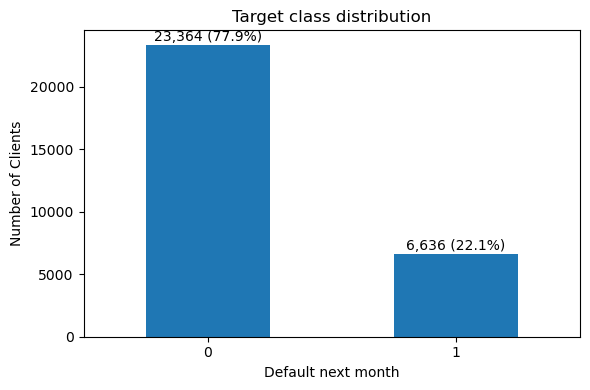

In [16]:
class_counts = y.value_counts().sort_index()
class_percent = (y.value_counts(normalize=True).sort_index() * 100)
display(pd.DataFrame({"count": class_counts, "percent": class_percent.round(2)}))

plt.figure(figsize=(6,4))
ax = class_counts.plot(kind="bar")
plt.title("Target class distribution")
plt.xlabel("Default next month")
plt.ylabel("Number of Clients")
plt.xticks(rotation=0)
for i, v in enumerate(class_counts.values):
    ax.text(i, v + len(y)*0.01, f"{v:,} ({class_percent.iloc[i]:.1f}%)", ha="center")
plt.tight_layout()
plt.show()

In [17]:
class_percent = y.value_counts(normalize=True).sort_index() * 100

print(class_percent)

default payment next month
0    77.88
1    22.12
Name: proportion, dtype: float64


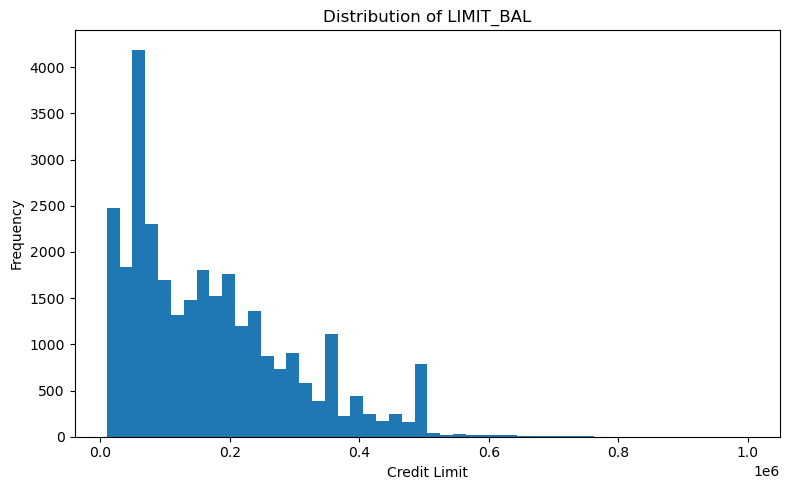

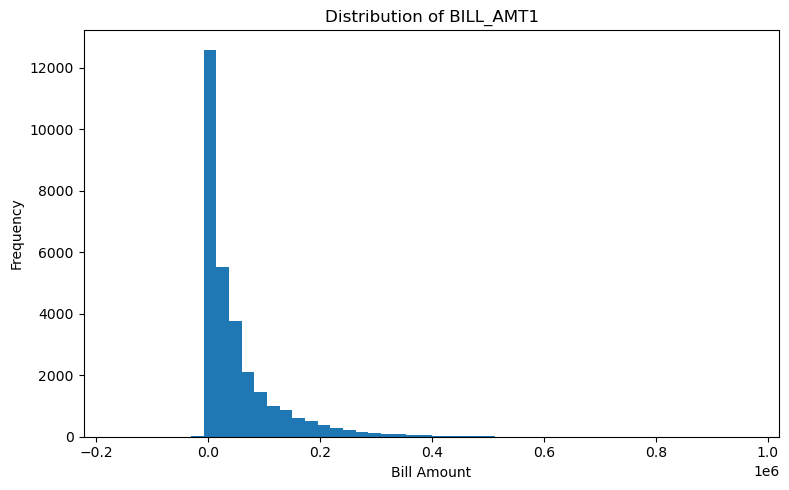

In [18]:
plt.figure(figsize=(8, 5))
plt.hist(X["LIMIT_BAL"], bins=50)
plt.title("Distribution of LIMIT_BAL")
plt.xlabel("Credit Limit")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(X["BILL_AMT1"], bins=50)
plt.title("Distribution of BILL_AMT1")
plt.xlabel("Bill Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

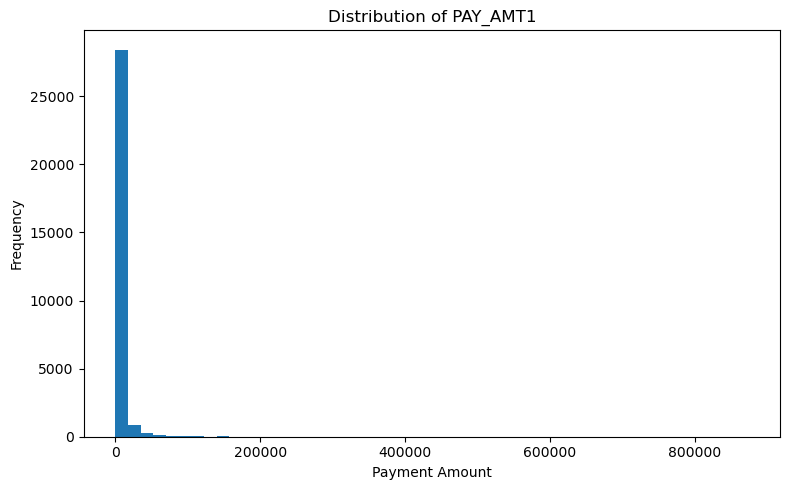

In [19]:
plt.figure(figsize=(8, 5))
plt.hist(X["PAY_AMT1"], bins=50)
plt.title("Distribution of PAY_AMT1")
plt.xlabel("Payment Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

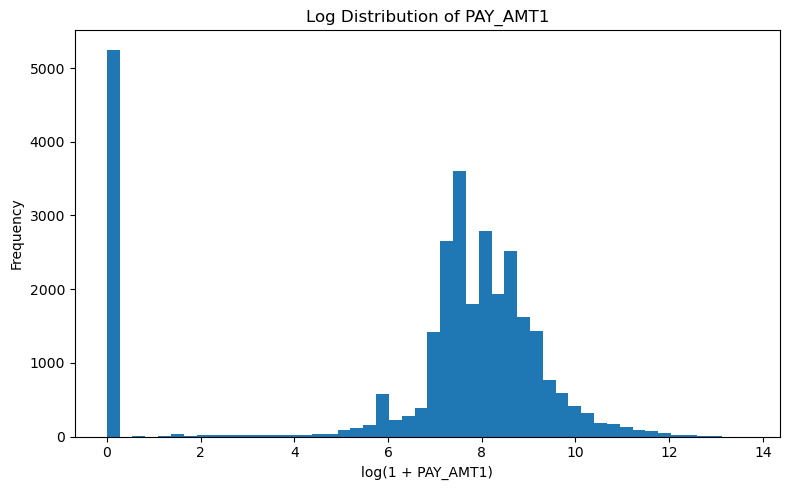

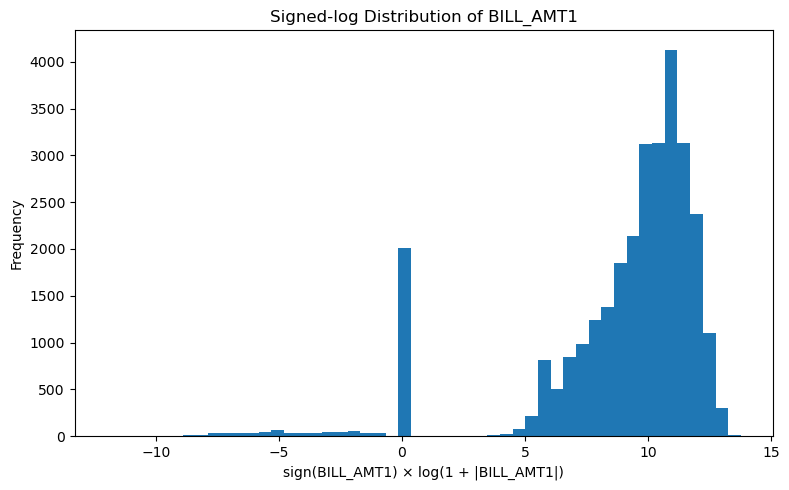

In [20]:
plt.figure(figsize=(8, 5))
plt.hist(np.log1p(X["PAY_AMT1"].clip(lower=0)), bins=50)
plt.title("Log Distribution of PAY_AMT1")
plt.xlabel("log(1 + PAY_AMT1)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

# BILL_AMT may contain valid negative values, so ordinary log1p is not appropriate.
# Signed-log preserves the sign while compressing the heavy-tailed magnitude.
signed_log_bill = np.sign(X["BILL_AMT1"]) * np.log1p(np.abs(X["BILL_AMT1"]))
plt.figure(figsize=(8, 5))
plt.hist(signed_log_bill, bins=50)
plt.title("Signed-log Distribution of BILL_AMT1")
plt.xlabel("sign(BILL_AMT1) × log(1 + |BILL_AMT1|)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

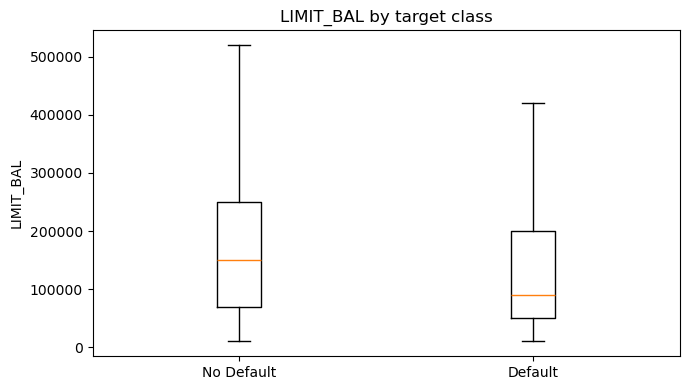

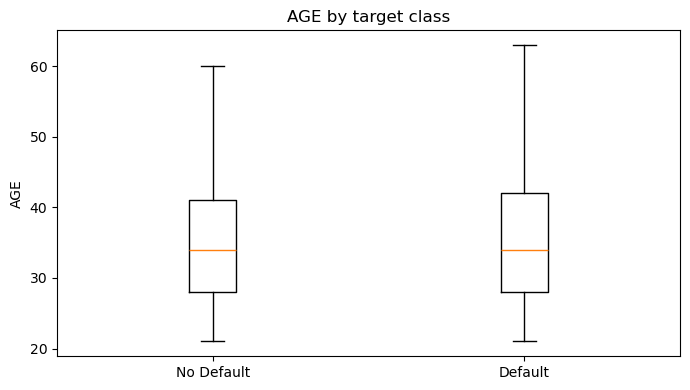

In [21]:
fig, ax = plt.subplots(figsize=(7,4))
ax.boxplot([df.loc[y==0,'LIMIT_BAL'], df.loc[y==1,'LIMIT_BAL']], labels=['No Default','Default'], showfliers=False)
ax.set_title('LIMIT_BAL by target class')
ax.set_ylabel('LIMIT_BAL')
plt.tight_layout();
plt.show()

fig, ax = plt.subplots(figsize=(7,4))
ax.boxplot([df.loc[y==0,'AGE'], df.loc[y==1,'AGE']], labels=['No Default','Default'], showfliers=False)
ax.set_title('AGE by target class')
ax.set_ylabel('AGE')
plt.tight_layout();
plt.show()

PAY_MAX_DELAY
-2    13.47
-1    14.71
 0    10.83
 1    24.99
 2    43.55
 3    62.23
 4    64.22
 5    50.72
 6    56.00
 7    83.58
 8    56.00
Name: default payment next month, dtype: float64


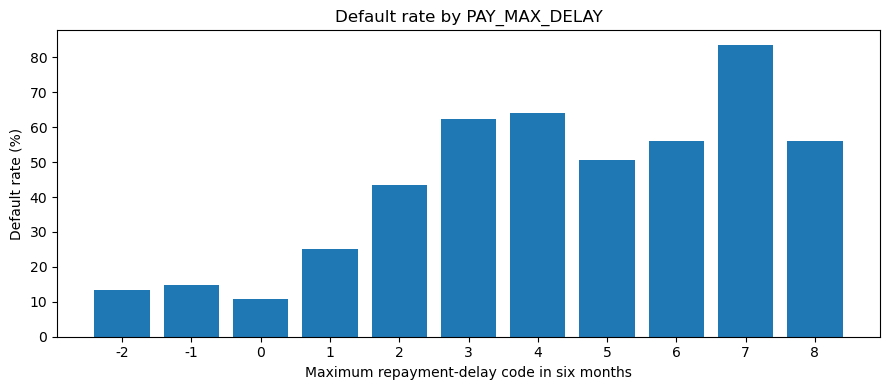

In [22]:
delay_rate = df.groupby('PAY_MAX_DELAY')[TARGET].mean().sort_index() * 100
print(delay_rate.round(2))

plt.figure(figsize=(9,4))
plt.bar(delay_rate.index.astype(str), delay_rate.values)
plt.xlabel('Maximum repayment-delay code in six months')
plt.ylabel('Default rate (%)')
plt.title('Default rate by PAY_MAX_DELAY')
plt.tight_layout(); 
plt.show()

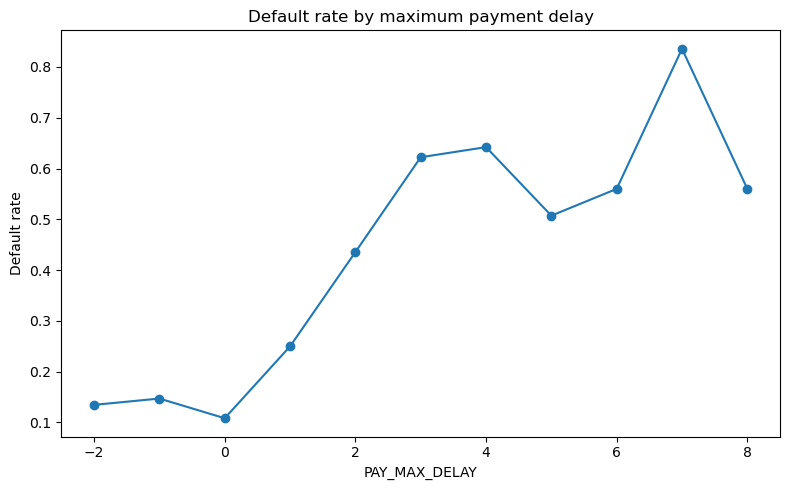

In [23]:
rate_by_delay=df.groupby('PAY_MAX_DELAY')[TARGET].mean().sort_index()
fig, ax=plt.subplots(figsize=(8,5));
ax.plot(rate_by_delay.index, rate_by_delay.values, marker='o');
ax.set_title('Default rate by maximum payment delay');
ax.set_xlabel('PAY_MAX_DELAY');
ax.set_ylabel('Default rate');
fig.tight_layout();
plt.show(); plt.close(fig)


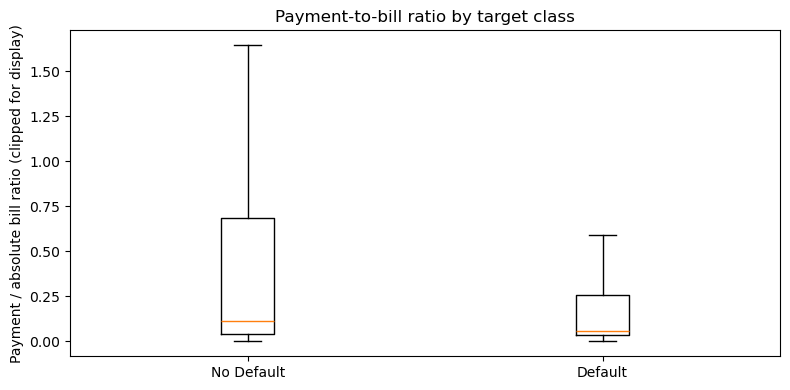

In [24]:
ratio_plot = df['PAYMENT_TO_BILL_RATIO_6M'].clip(-1, 5)
plt.figure(figsize=(8,4))
plt.boxplot([ratio_plot[y==0], ratio_plot[y==1]], labels=['No Default','Default'], showfliers=False)
plt.ylabel('Payment / absolute bill ratio (clipped for display)')
plt.title('Payment-to-bill ratio by target class')
plt.tight_layout();
plt.show()

In [25]:
summary_by_target = (
    df.groupby("default payment next month")[
        ["LIMIT_BAL", "AGE", "PAY_0", "BILL_AMT1", "PAY_AMT1"]
    ]
    .median()
)

display(summary_by_target)

,LIMIT_BAL,AGE,PAY_0,BILL_AMT1,PAY_AMT1
default payment next month,,,,,
0,150000.0,34.0,0.0,23119.5,2459.5
1,90000.0,34.0,1.0,20185.0,1636.0


## 7. Leakage-safe preprocessing and baseline models

In [26]:
def make_preprocessor(scaler='standard'):
    if scaler == 'standard':
        scaler_obj = StandardScaler()
    elif scaler == 'robust':
        scaler_obj = RobustScaler()
    elif scaler == 'yeojohnson_robust':
        scaler_obj = Pipeline([
            ('power', PowerTransformer(method='yeo-johnson', standardize=False)),
            ('robust', RobustScaler())
        ])
    else:
        raise ValueError('Unknown scaler')
    return ColumnTransformer([
        ('num', Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', scaler_obj)]), numeric_cols),
        ('cat', Pipeline([('imputer', SimpleImputer(strategy='most_frequent')), ('onehot', OneHotEncoder(handle_unknown='ignore'))]), categorical_cols)
    ])

def make_pipeline(model, scaler='standard'):
    return Pipeline([('prep', make_preprocessor(scaler)), ('model', model)])

In [27]:
models = {
    'Dummy': make_pipeline(DummyClassifier(strategy='prior'), 'standard'),
    'Logistic Regression': make_pipeline(LogisticRegression(max_iter=1200, class_weight='balanced', random_state=RANDOM_STATE), 'standard'),
    'Random Forest': make_pipeline(RandomForestClassifier(n_estimators=50, max_depth=8, min_samples_leaf=5, max_features='sqrt', class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1), 'robust')
}

model_rows=[]
for name, pipe in models.items():
    t0=time.time(); pipe.fit(X_fit,y_fit); runtime=time.time()-t0
    p=pipe.predict_proba(X_val)[:,1]
    model_rows.append({
        'model':name,'validation_ap':average_precision_score(y_val,p),'validation_roc_auc':roc_auc_score(y_val,p),
        'validation_brier':brier_score_loss(y_val,p),'runtime_sec':runtime
    })
model_comparison=pd.DataFrame(model_rows).sort_values('validation_ap',ascending=False)
model_comparison

,model,validation_ap,validation_roc_auc,validation_brier,runtime_sec
2,Random Forest,0.551494,0.781142,0.174419,0.338184
1,Logistic Regression,0.538239,0.767714,0.182553,0.182904
0,Dummy,0.221167,0.500000,0.172252,0.065042


## 8. Robust preprocessing comparison

,preprocessing,validation_ap,validation_recall_at_0_5,validation_brier,runtime_sec
0,standard,0.552571,0.601356,0.176131,0.196935
1,robust,0.546565,0.610399,0.176238,0.207151
2,yeojohnson_robust,0.546833,0.610399,0.176210,0.404654


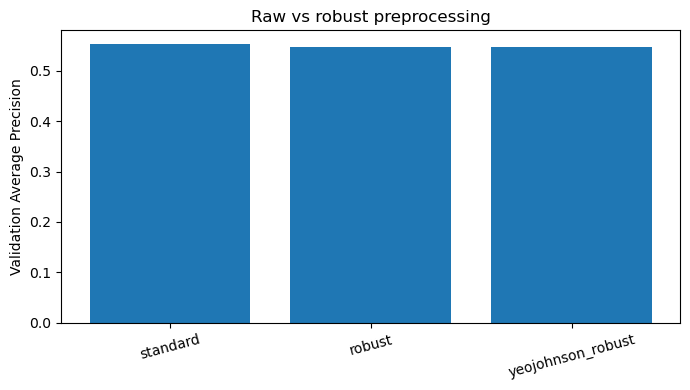

In [28]:
rf_base = RandomForestClassifier(n_estimators=15,max_depth=8,min_samples_leaf=5,max_features='sqrt',class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1)
robust_rows=[]
for scaler in ['standard','robust','yeojohnson_robust']:
    pipe=make_pipeline(rf_base,scaler)
    t0=time.time(); pipe.fit(X_fit,y_fit); rt=time.time()-t0
    p=pipe.predict_proba(X_val)[:,1]
    robust_rows.append({'preprocessing':scaler,'validation_ap':average_precision_score(y_val,p),'validation_recall_at_0_5':recall_score(y_val,p>=0.5),'validation_brier':brier_score_loss(y_val,p),'runtime_sec':rt})
robust_comparison=pd.DataFrame(robust_rows)
display(robust_comparison)
plt.figure(figsize=(7,4));
plt.bar(robust_comparison['preprocessing'],robust_comparison['validation_ap']);
plt.ylabel('Validation Average Precision');
plt.title('Raw vs robust preprocessing');
plt.xticks(rotation=15);
plt.tight_layout();
plt.show()

## 9A. Outlier policy and raw-vs-robust class-wise comparison

Financial extremes are not deleted automatically. To document the outlier policy, percentile thresholds are estimated from the internal Fit subset only and are used only as diagnostic clipping limits; Test is never used to construct them. The main robust comparisons remain pipeline-based (StandardScaler, RobustScaler, and Yeo-Johnson + RobustScaler).


In [29]:
# Train-only diagnostic thresholds for financial variables (not used to delete observations).
financial_cols=['LIMIT_BAL']+bill_cols+pay_amt_cols
outlier_rows=[]
for col in financial_cols:
    q01=float(X_fit[col].quantile(0.01)); q99=float(X_fit[col].quantile(0.99))
    n_low=int((X_val[col]<q01).sum()); n_high=int((X_val[col]>q99).sum())
    outlier_rows.append({'feature':col,'train_q01':q01,'train_q99':q99,'validation_below_q01':n_low,'validation_above_q99':n_high})
train_outlier_thresholds=pd.DataFrame(outlier_rows)
display(train_outlier_thresholds)
print('All diagnostic outlier thresholds above were learned from X_fit only; no rows are deleted.')

# Class-wise comparison of the two main preprocessing choices on Validation.
classwise_rows=[]
for label,scaler in [('StandardScaler','standard'),('RobustScaler','robust')]:
    pipe=make_pipeline(RandomForestClassifier(n_estimators=50,max_depth=8,min_samples_leaf=5,max_features='sqrt',class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1),scaler)
    pipe.fit(X_fit,y_fit)
    pred=(pipe.predict_proba(X_val)[:,1]>=0.5).astype(int)
    for cls in [0,1]:
        classwise_rows.append({'preprocessing':label,'class':cls,'precision':precision_score(y_val,pred,pos_label=cls,zero_division=0),'recall':recall_score(y_val,pred,pos_label=cls,zero_division=0),'f1':f1_score(y_val,pred,pos_label=cls,zero_division=0)})
classwise_comparison=pd.DataFrame(classwise_rows)
display(classwise_comparison)


,feature,train_q01,train_q99,validation_below_q01,validation_above_q99
0,LIMIT_BAL,10000.00,500000.00,0,46
1,BILL_AMT1,-93.02,342622.88,50,72
2,BILL_AMT2,-186.05,332078.58,50,62
3,BILL_AMT3,-200.00,324111.13,40,56
4,BILL_AMT4,-239.01,306082.72,45,53
5,BILL_AMT5,-281.05,284627.90,38,61
6,BILL_AMT6,-383.04,273018.77,41,63
7,PAY_AMT1,0.00,69033.88,0,50
8,PAY_AMT2,0.00,78080.13,0,59
9,PAY_AMT3,0.00,77011.78,0,40


All diagnostic outlier thresholds above were learned from X_fit only; no rows are deleted.


,preprocessing,class,precision,recall,f1
0,StandardScaler,0,0.879549,0.817248,0.847255
1,StandardScaler,1,0.484922,0.605878,0.538693
2,RobustScaler,0,0.881616,0.812754,0.845786
3,RobustScaler,1,0.482861,0.615674,0.541239


## 9. Train-only hyperparameter search

In [30]:
search_pipe = make_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced', n_jobs=-1),
    'robust'
)
param_dist = {
    'model__n_estimators': randint(40, 81),
    'model__max_depth': [None] + list(range(5, 21)),
    'model__min_samples_split': randint(2, 16),
    'model__min_samples_leaf': randint(1, 16),
    'model__max_features': ['sqrt', 'log2', 0.5, 0.75],
    'model__class_weight': ['balanced', 'balanced_subsample']
}
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search = RandomizedSearchCV(
    search_pipe, param_dist, n_iter=10, scoring='average_precision', cv=cv,
    random_state=RANDOM_STATE, n_jobs=-1, return_train_score=True, refit=False
)
t0=time.time(); search.fit(X_fit,y_fit); search_runtime=time.time()-t0
best_params=search.best_params_
print('Search data:', X_fit.shape)
print('Search budget: 10 randomized configurations x 5-fold stratified CV')
print('Optimization metric: Average Precision (PR-AUC)')
print('Best params from train-only search:',best_params)
print('Best CV AP:',search.best_score_)
print('Search runtime:',round(search_runtime,2),'sec')
cv_results=pd.DataFrame(search.cv_results_).sort_values('rank_test_score')
display(cv_results[['params','mean_test_score','std_test_score','mean_train_score','rank_test_score']])

# Selected hyperparameters are now fixed. Fit the selected model on the entire 80% Train pool.
rf_params={k.replace('model__',''):v for k,v in best_params.items()}
best_rf=RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1,**rf_params)
best_model=make_pipeline(best_rf,'robust')
t0=time.time(); best_model.fit(X_train,y_train); full_fit_runtime=time.time()-t0
print('Final model fit on full 80% Train pool runtime:',round(full_fit_runtime,2),'sec')

Search data: (18000, 28)
Search budget: 10 randomized configurations x 5-fold stratified CV
Optimization metric: Average Precision (PR-AUC)
Best params from train-only search: {'model__class_weight': 'balanced', 'model__max_depth': 5, 'model__max_features': 0.75, 'model__min_samples_leaf': 12, 'model__min_samples_split': 13, 'model__n_estimators': 46}
Best CV AP: 0.5581689591795713
Search runtime: 40.68 sec


,params,mean_test_score,std_test_score,mean_train_score,rank_test_score
8,"{'model__class_weight': 'balanced', 'model__ma...",0.558169,0.015357,0.592572,1
1,"{'model__class_weight': 'balanced', 'model__ma...",0.557913,0.014347,0.829218,2
9,"{'model__class_weight': 'balanced_subsample', ...",0.557717,0.015817,0.770385,3
6,"{'model__class_weight': 'balanced', 'model__ma...",0.556589,0.011652,0.681477,4
5,"{'model__class_weight': 'balanced_subsample', ...",0.555966,0.013377,0.779512,5
7,"{'model__class_weight': 'balanced_subsample', ...",0.555732,0.011276,0.711216,6
4,"{'model__class_weight': 'balanced_subsample', ...",0.554476,0.014092,0.852151,7
0,"{'model__class_weight': 'balanced', 'model__ma...",0.554021,0.012646,0.857942,8
3,"{'model__class_weight': 'balanced_subsample', ...",0.552083,0.015414,0.626086,9
2,"{'model__class_weight': 'balanced_subsample', ...",0.541897,0.012653,0.576442,10


Final model fit on full 80% Train pool runtime: 1.04 sec


**Budget justification:** The initial project analysis proposed a larger search budget, but the executed 10-configuration × 5-fold search already required about 345 seconds on the available environment. The smaller fixed budget is therefore documented as a runtime-constrained, reproducible compromise rather than an unreported arbitrary grid.


In [31]:
validation_model = make_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1,**rf_params),
    'robust'
)
validation_model.fit(X_fit,y_fit)
p_val = validation_model.predict_proba(X_val)[:,1]
print('Validation AP:',average_precision_score(y_val,p_val))
print('Validation ROC-AUC:',roc_auc_score(y_val,p_val))

Validation AP: 0.5480935966572138
Validation ROC-AUC: 0.7788253835506802


## 9. Validation threshold analysis

threshold         0.375000
cost           3296.000000
review_rate       0.476500
recall            0.778448
precision         0.361315
f1                0.493550
tp             1033.000000
fp             1826.000000
fn              294.000000
tn             2847.000000
Name: 65, dtype: float64

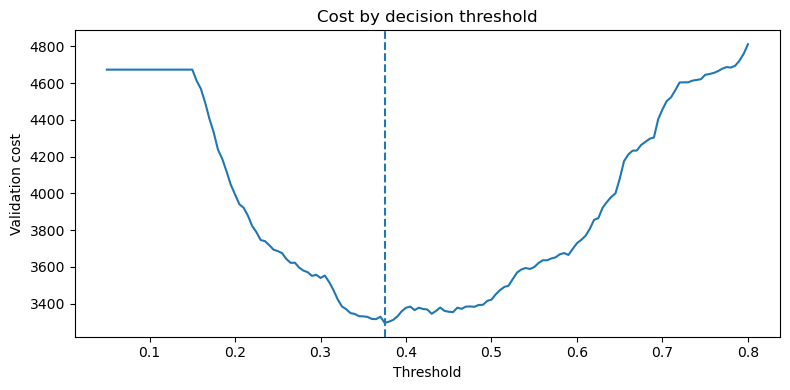

threshold= 0.375 cost= 3296.0 review= 0.4765
threshold= 0.5 cost= 3422.0 review= 0.3105


In [32]:
FN_COST=5
FP_COST=1
thresholds=np.linspace(0.05,0.80,151)
threshold_rows=[]
for th in thresholds:
    pred=(p_val>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_val,pred,labels=[0,1]).ravel()
    cost=FN_COST*fn+FP_COST*fp
    threshold_rows.append({'threshold':th,'cost':cost,'review_rate':pred.mean(),'recall':recall_score(y_val,pred),'precision':precision_score(y_val,pred,zero_division=0),'f1':f1_score(y_val,pred,zero_division=0),'tp':tp,'fp':fp,'fn':fn,'tn':tn})
th_df=pd.DataFrame(threshold_rows)
best_threshold_row=th_df.loc[th_df['cost'].idxmin()]
best_threshold=float(best_threshold_row['threshold'])
display(best_threshold_row)

plt.figure(figsize=(8,4));
plt.plot(th_df['threshold'],th_df['cost']);
plt.axvline(best_threshold,linestyle='--');
plt.xlabel('Threshold');
plt.ylabel('Validation cost');
plt.title('Cost by decision threshold');
plt.tight_layout();
plt.show()

for th in [best_threshold,0.5]:
    row=th_df.iloc[(th_df['threshold']-th).abs().argmin()]
    print('threshold=',row['threshold'],'cost=',row['cost'],'review=',row['review_rate'])

## 10. Calibration and final Validation threshold

Validation Brier: 0.13563773406814925


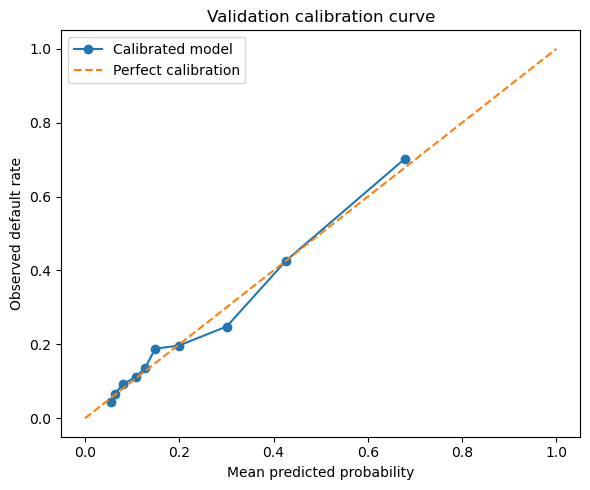

In [33]:
calibration_base = make_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1,**rf_params),
    'robust'
)
calibrated = CalibratedClassifierCV(calibration_base, method='sigmoid', cv=5)
t0=time.time(); calibrated.fit(X_fit,y_fit); calibration_runtime=time.time()-t0
p_val_cal=calibrated.predict_proba(X_val)[:,1]
print('Validation Brier:',brier_score_loss(y_val,p_val_cal))

prob_true, prob_pred = calibration_curve(y_val,p_val_cal,n_bins=10,strategy='quantile')
plt.figure(figsize=(6,5));
plt.plot(prob_pred,prob_true,marker='o',label='Calibrated model');
plt.plot([0,1],[0,1],linestyle='--',label='Perfect calibration');
plt.xlabel('Mean predicted probability');
plt.ylabel('Observed default rate');
plt.title('Validation calibration curve');
plt.legend();
plt.tight_layout();
plt.show()

threshold         0.130000
cost           3306.000000
review_rate       0.537167
recall            0.822909
precision         0.338815
f1                0.480000
Name: 16, dtype: float64


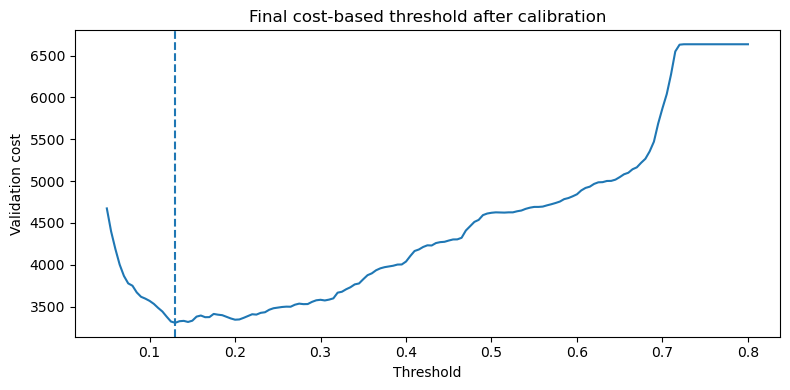

,threshold,cost,review_rate,recall_default,precision_default,F1_default,FN,FP,TN,TP
0,0.13,3306,0.537167,0.822909,0.338815,0.480000,235,2131,2542,1092
1,0.50,4621,0.106333,0.333082,0.692790,0.449873,885,196,4477,442


Selected threshold is based only on internal Validation; Test has not been used.


In [34]:
thresholds_cal=np.linspace(0.05,0.80,151)
threshold_cal_rows=[]
for th in thresholds_cal:
    pred=(p_val_cal>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_val,pred,labels=[0,1]).ravel()
    cost=FN_COST*fn+FP_COST*fp
    threshold_cal_rows.append({'threshold':th,'cost':cost,'review_rate':pred.mean(),'recall':recall_score(y_val,pred),'precision':precision_score(y_val,pred,zero_division=0),'f1':f1_score(y_val,pred,zero_division=0)})
threshold_cal_df=pd.DataFrame(threshold_cal_rows)
best_threshold_row=threshold_cal_df.loc[threshold_cal_df['cost'].idxmin()]
best_threshold=float(best_threshold_row['threshold'])
print(best_threshold_row)
plt.figure(figsize=(8,4));
plt.plot(threshold_cal_df['threshold'],threshold_cal_df['cost']);
plt.axvline(best_threshold,linestyle='--');
plt.xlabel('Threshold'); plt.ylabel('Validation cost');
plt.title('Final cost-based threshold after calibration');
plt.tight_layout();
plt.show()
# Required operational comparison: at least two thresholds.
operational_thresholds=sorted(set([0.50,round(best_threshold,3)]))
operational_rows=[]
for th in operational_thresholds:
    pred=(p_val_cal>=th).astype(int)
    tn,fp,fn,tp=confusion_matrix(y_val,pred,labels=[0,1]).ravel()
    operational_rows.append({'threshold':th,'cost':FN_COST*fn+FP_COST*fp,'review_rate':pred.mean(),'recall_default':recall_score(y_val,pred),'precision_default':precision_score(y_val,pred,zero_division=0),'F1_default':f1_score(y_val,pred,zero_division=0),'FN':fn,'FP':fp,'TN':tn,'TP':tp})
operational_threshold_df=pd.DataFrame(operational_rows).sort_values('threshold')
display(operational_threshold_df)

print('Selected threshold is based only on internal Validation; Test has not been used.')

## 11. Genetic Algorithm feature selection

In [35]:
# Genetic Algorithm feature selection is independent from the final Test evaluation.
# The chromosome represents the 23 ORIGINAL predictor features, as required by the project/GA analysis.
original_ga_features = [
    'LIMIT_BAL','SEX','EDUCATION','MARRIAGE','AGE',
    'PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6',
    'BILL_AMT1','BILL_AMT2','BILL_AMT3','BILL_AMT4','BILL_AMT5','BILL_AMT6',
    'PAY_AMT1','PAY_AMT2','PAY_AMT3','PAY_AMT4','PAY_AMT5','PAY_AMT6'
]
sensitive_features=['SEX','EDUCATION','MARRIAGE','AGE']
ga_features=original_ga_features.copy()

# Fit preprocessing only on the GA fit subset. Validation is used only to score chromosomes.
# IMPORTANT: the GA chromosome contains exactly the 23 original predictors, so its
# preprocessor must also reference only those columns (not the engineered model features).
ga_numeric=[f for f in ['LIMIT_BAL','AGE'] + bill_cols + pay_amt_cols if f in ga_features]
ga_categorical=[f for f in ['SEX','EDUCATION','MARRIAGE'] + pay_cols if f in ga_features]
ga_prep=ColumnTransformer([
    ('num',Pipeline([('imputer',SimpleImputer(strategy='median')),('scaler',StandardScaler())]),ga_numeric),
    ('cat',Pipeline([('imputer',SimpleImputer(strategy='most_frequent')),('onehot',OneHotEncoder(handle_unknown='ignore'))]),ga_categorical)
])
ga_prep.fit(X_fit[ga_features],y_fit)
Xtr_ga=ga_prep.transform(X_fit[ga_features])
Xva_ga=ga_prep.transform(X_val[ga_features])
transformed_names=ga_prep.get_feature_names_out()
feature_to_indices={}
for feature in ga_features:
    prefix_num='num__'+feature
    prefix_cat='cat__'+feature+'_'
    idx=[j for j,name in enumerate(transformed_names) if name==prefix_num or name.startswith(prefix_cat)]
    feature_to_indices[feature]=idx

print('Original GA feature count:',len(ga_features))
print('GA settings: population=16, generations=8, elitism=1, one-point crossover, mutation=0.08, min_features=4')
print('GA seeds: [11, 22, 33]')

ga_fitness_cache = {}

def ga_fitness(mask, features, seed):
    key=(tuple(int(v) for v in mask), tuple(features), int(seed))
    if key in ga_fitness_cache:
        return ga_fitness_cache[key]
    selected=[f for f,m in zip(features,mask) if m]
    if len(selected) < 4:
        ga_fitness_cache[key]=(-1e9,0)
        return ga_fitness_cache[key]
    indices=[j for f in selected for j in feature_to_indices[f]]
    model=LogisticRegression(max_iter=400,class_weight='balanced',random_state=seed,solver='liblinear')
    model.fit(Xtr_ga[:,indices],y_fit)
    pv=model.predict_proba(Xva_ga[:,indices])[:,1]
    ap=average_precision_score(y_val,pv)
    # Report-aligned fitness: Validation PR-AUC minus 0.005 * feature proportion.
    fitness=ap-0.005*(len(selected)/len(features))
    ga_fitness_cache[key]=(fitness,ap)
    return ga_fitness_cache[key]

def run_ga(features, seed, population_size=16, generations=8, mutation_rate=0.08, min_features=4):
    rng=np.random.default_rng(seed)
    pop=rng.integers(0,2,size=(population_size,len(features)),dtype=int)
    for i in range(population_size):
        while pop[i].sum()<min_features:
            pop[i,rng.integers(0,len(features))]=1
    history=[]; best_mask=None; best_fit=-1e9; best_ap=0
    for gen in range(generations):
        scored=[]
        for mask in pop:
            fit,ap=ga_fitness(mask,features,seed)
            scored.append((fit,ap,mask.copy()))
        scored.sort(key=lambda x:x[0],reverse=True)
        history.append({'seed':seed,'generation':gen+1,'fitness':scored[0][0],'ap':scored[0][1],'n_features':int(scored[0][2].sum())})
        if scored[0][0]>best_fit:
            best_fit,best_ap,best_mask=scored[0]
        # Elitism = 1
        new_pop=[scored[0][2].copy()]
        while len(new_pop)<population_size:
            p1=scored[rng.integers(0,len(scored))][2]
            p2=scored[rng.integers(0,len(scored))][2]
            cut=rng.integers(1,len(features))
            child=np.concatenate([p1[:cut],p2[cut:]])
            mutation=rng.random(len(features))<mutation_rate
            child[mutation]=1-child[mutation]
            while child.sum()<min_features:
                child[rng.integers(0,len(features))]=1
            new_pop.append(child)
        pop=np.array(new_pop)
    selected=[f for f,m in zip(features,best_mask) if m]
    return {'seed':seed,'fitness':best_fit,'validation_ap':best_ap,'n_features':len(selected),'features':selected,'history':history}

ga_results=[]; ga_hist=[]
for scenario, excluded in [('with_sensitive',[]),('without_sensitive',sensitive_features)]:
    features=[f for f in ga_features if f not in excluded]
    for seed in [11,22,33]:
        t0=time.time(); res=run_ga(features,seed); res['scenario']=scenario; res['runtime_sec']=time.time()-t0
        ga_results.append(res); ga_hist.extend(res['history'])
        print(scenario,seed,res['n_features'],round(res['validation_ap'],4),round(res['fitness'],4))

ga_summary=pd.DataFrame([{k:v for k,v in r.items() if k!='features' and k!='history'} for r in ga_results])
ga_summary

Original GA feature count: 23
GA settings: population=16, generations=8, elitism=1, one-point crossover, mutation=0.08, min_features=4
GA seeds: [11, 22, 33]
with_sensitive 11 14 0.537 0.5339
with_sensitive 22 8 0.537 0.5352
with_sensitive 33 13 0.5369 0.534
without_sensitive 11 12 0.5333 0.5302
without_sensitive 22 10 0.5357 0.5331
without_sensitive 33 8 0.5346 0.5325


,seed,fitness,validation_ap,n_features,scenario,runtime_sec
0,11,0.533929,0.536972,14,with_sensitive,7.504862
1,22,0.535241,0.536980,8,with_sensitive,5.908285
2,33,0.534043,0.536869,13,with_sensitive,6.285658
3,11,0.530170,0.533328,12,without_sensitive,4.508052
4,22,0.533068,0.535699,10,without_sensitive,4.836756
5,33,0.532501,0.534607,8,without_sensitive,4.293287


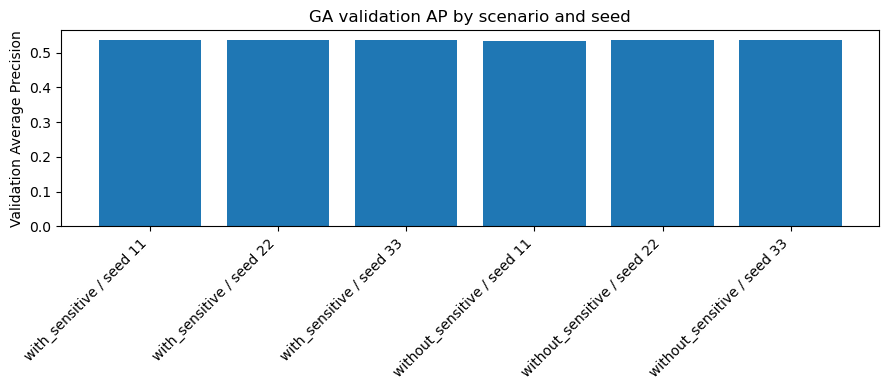

Best with sensitive: 8 ['PAY_0', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT5']
Best without sensitive: 10 ['PAY_0', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT4', 'PAY_AMT2', 'PAY_AMT5', 'PAY_AMT6']


In [36]:
# نمودار GA: بهترین Validation AP هر seed
plot_ga=ga_summary.copy(); plot_ga['label']=plot_ga['scenario']+' / seed '+plot_ga['seed'].astype(str)
plt.figure(figsize=(9,4)); 
plt.bar(plot_ga['label'],plot_ga['validation_ap']); 
plt.xticks(rotation=45,ha='right'); 
plt.ylabel('Validation Average Precision');
plt.title('GA validation AP by scenario and seed');
plt.tight_layout();
plt.show()

best_with=max([r for r in ga_results if r['scenario']=='with_sensitive'],key=lambda r:r['fitness'])
best_without=max([r for r in ga_results if r['scenario']=='without_sensitive'],key=lambda r:r['fitness'])
print('Best with sensitive:',best_with['n_features'],best_with['features'])
print('Best without sensitive:',best_without['n_features'],best_without['features'])

## 12. GA stability across seeds

In [37]:
def jaccard(a,b):
    A=set(a); B=set(b)
    return len(A&B)/len(A|B) if A|B else 1.0
stability_rows=[]
for scenario in ['with_sensitive','without_sensitive']:
    rs=[r for r in ga_results if r['scenario']==scenario]
    for i in range(len(rs)):
        for j in range(i+1,len(rs)):
            stability_rows.append({'scenario':scenario,'seed_a':rs[i]['seed'],'seed_b':rs[j]['seed'],'jaccard':jaccard(rs[i]['features'],rs[j]['features'])})
stability=pd.DataFrame(stability_rows)
display(stability)
print(stability.groupby('scenario')['jaccard'].mean())

,scenario,seed_a,seed_b,jaccard
0,with_sensitive,11,22,0.375000
1,with_sensitive,11,33,0.687500
2,with_sensitive,22,33,0.400000
3,without_sensitive,11,22,0.375000
4,without_sensitive,11,33,0.428571
5,without_sensitive,22,33,0.384615


scenario
with_sensitive       0.487500
without_sensitive    0.396062
Name: jaccard, dtype: float64


## 13. All features vs GA-selected features

,model,n_features,validation_ap,validation_roc_auc,validation_brier,runtime_sec
0,All features,28,0.551494,0.781142,0.174419,0.356545
1,GA with sensitive,8,0.538986,0.767643,0.183026,0.178833
2,GA without sensitive,10,0.537167,0.766894,0.181311,0.195019


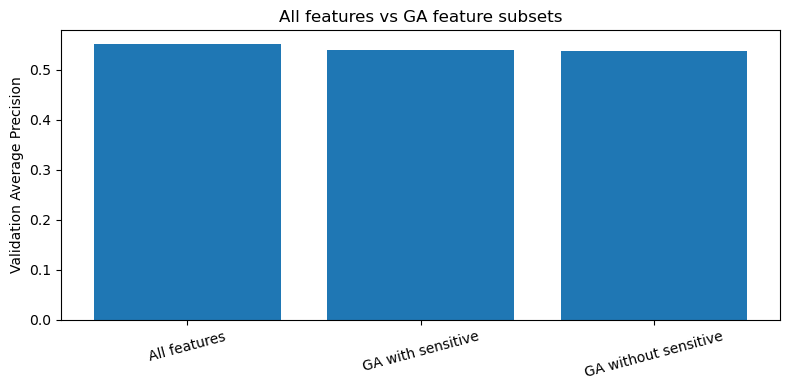

In [38]:
def fit_rf_on_features(features):
    num=[f for f in features if f in numeric_cols]; cat=[f for f in features if f in categorical_cols]
    prep=ColumnTransformer([
        ('num',Pipeline([('imp',SimpleImputer(strategy='median')),('scale',RobustScaler())]),num),
        ('cat',Pipeline([('imp',SimpleImputer(strategy='most_frequent')),('oh',OneHotEncoder(handle_unknown='ignore'))]),cat)
    ])
    return Pipeline([('prep',prep),('rf',RandomForestClassifier(n_estimators=50,max_depth=8,min_samples_leaf=5,max_features='sqrt',class_weight='balanced',random_state=RANDOM_STATE,n_jobs=-1))])

comparison_features={'All features':model_features,'GA with sensitive':best_with['features'],'GA without sensitive':best_without['features']}
comparison_rows=[]; fitted_models={}
for name,features in comparison_features.items():
    pipe=fit_rf_on_features(features); t0=time.time(); pipe.fit(X_fit[features],y_fit); rt=time.time()-t0
    pv=pipe.predict_proba(X_val[features])[:,1]
    comparison_rows.append({'model':name,'n_features':len(features),'validation_ap':average_precision_score(y_val,pv),'validation_roc_auc':roc_auc_score(y_val,pv),'validation_brier':brier_score_loss(y_val,pv),'runtime_sec':rt})
    fitted_models[name]=pipe
comparison_df=pd.DataFrame(comparison_rows); 
display(comparison_df)
plt.figure(figsize=(8,4));
plt.bar(comparison_df['model'],comparison_df['validation_ap']);
plt.ylabel('Validation Average Precision');
plt.title('All features vs GA feature subsets');
plt.xticks(rotation=15);
plt.tight_layout();
plt.show()

## 14. Controlled noise sensitivity

In [39]:
# Controlled-noise sensitivity on Validation only. Test remains untouched.
X_val_noise=X_val.copy()
rng=np.random.default_rng(123)
X_val_noise['LIMIT_BAL']=X_val_noise['LIMIT_BAL']*(1+rng.normal(0,0.03,len(X_val_noise)))
X_val_noise['PAY_AMT1']=X_val_noise['PAY_AMT1']*(1+rng.normal(0,0.03,len(X_val_noise)))
p_val_noise=calibrated.predict_proba(X_val_noise)[:,1]
original_pred=p_val_cal>=best_threshold
noise_pred=p_val_noise>=best_threshold
original_cm=confusion_matrix(y_val,original_pred,labels=[0,1]).ravel()
noise_cm=confusion_matrix(y_val,noise_pred,labels=[0,1]).ravel()
def classification_cost(cm):
    tn,fp,fn,tp=cm
    return FN_COST*fn+FP_COST*fp
sensitivity_df=pd.DataFrame([
    {'condition':'original','validation_ap':average_precision_score(y_val,p_val_cal),'recall_at_final_threshold':recall_score(y_val,original_pred),'cost_at_final_threshold':classification_cost(original_cm)},
    {'condition':'controlled_noise','validation_ap':average_precision_score(y_val,p_val_noise),'recall_at_final_threshold':recall_score(y_val,noise_pred),'cost_at_final_threshold':classification_cost(noise_cm)}
])
display(sensitivity_df)


,condition,validation_ap,recall_at_final_threshold,cost_at_final_threshold
0,original,0.550297,0.822909,3306
1,controlled_noise,0.550153,0.822909,3309


## 15. Locked Test evaluation

In [40]:
# All model/tuning/threshold decisions are now locked. Test is used for the final evaluation only.
final_calibration_base = make_pipeline(
    RandomForestClassifier(random_state=RANDOM_STATE,n_jobs=-1,**rf_params),
    'robust'
)
final_calibrated = CalibratedClassifierCV(final_calibration_base, method='sigmoid', cv=5)
t0=time.time(); final_calibrated.fit(X_train,y_train); final_calibration_runtime=time.time()-t0
p_test=final_calibrated.predict_proba(X_test)[:,1]
y_test_pred=(p_test>=best_threshold).astype(int)
tn,fp,fn,tp=confusion_matrix(y_test,y_test_pred,labels=[0,1]).ravel()

test_metrics={
    'AUC_PR':average_precision_score(y_test,p_test),
    'ROC_AUC':roc_auc_score(y_test,p_test),
    'Precision_default':precision_score(y_test,y_test_pred,zero_division=0),
    'Recall_default':recall_score(y_test,y_test_pred,zero_division=0),
    'F1_default':f1_score(y_test,y_test_pred,zero_division=0),
    'Macro_F1':f1_score(y_test,y_test_pred,average='macro'),
    'Brier':brier_score_loss(y_test,p_test),
    'TN':tn,'FP':fp,'FN':fn,'TP':tp,
    'Cost':FN_COST*fn+FP_COST*fp,
    'Review_rate':y_test_pred.mean(),
    'Threshold':best_threshold
}
pd.Series(test_metrics)

AUC_PR                  0.550526
ROC_AUC                 0.778058
Precision_default       0.340736
Recall_default          0.809344
F1_default              0.479571
Macro_F1                0.584820
Brier                   0.136168
TN                   2595.000000
FP                   2078.000000
FN                    253.000000
TP                   1074.000000
Cost                 3343.000000
Review_rate             0.525333
Threshold               0.130000
dtype: float64

### Why the Test curves are based on the final model

The Precision–Recall and calibration curves below are the required final-model diagnostics. They use the probabilities from the tuned, sigmoid-calibrated Random Forest evaluated once on the locked Test set. The GA is a separate feature-selection experiment and is compared on Validation; therefore its curves/metrics are not expected to numerically match the final-model curves. The decision threshold does not change either curve because both are based on continuous predicted probabilities.


## 16. Test PR and ROC curves

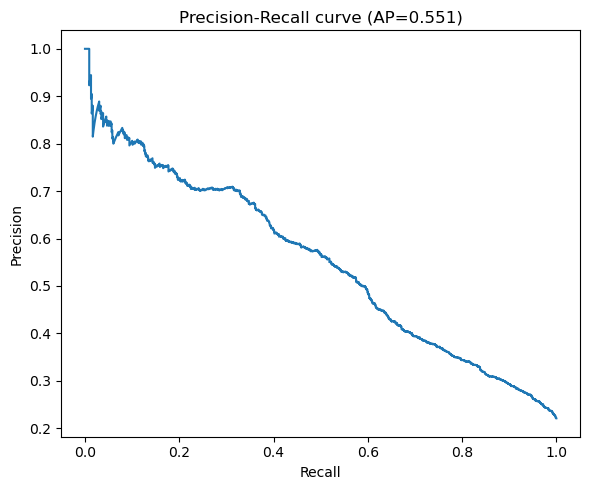

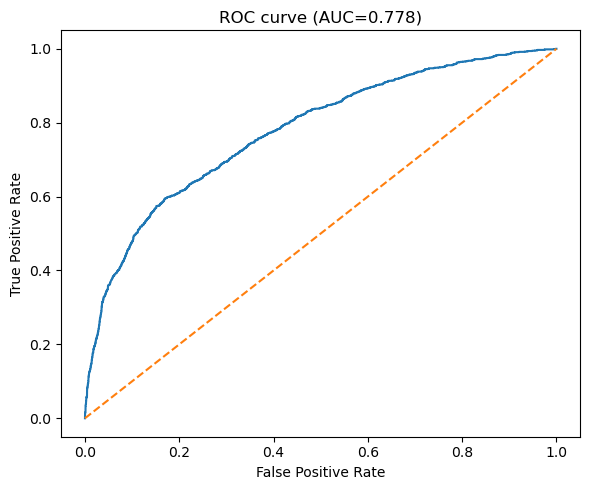

In [41]:
precision,recall,_=precision_recall_curve(y_test,p_test)
plt.figure(figsize=(6,5));
plt.plot(recall,precision);
plt.xlabel('Recall');
plt.ylabel('Precision');
plt.title(f'Precision-Recall curve (AP={test_metrics["AUC_PR"]:.3f})');
plt.tight_layout(); 
plt.show()

fpr,tpr,_=roc_curve(y_test,p_test)
plt.figure(figsize=(6,5));
plt.plot(fpr,tpr);
plt.plot([0,1],[0,1],linestyle='--');
plt.xlabel('False Positive Rate');
plt.ylabel('True Positive Rate'); 
plt.title(f'ROC curve (AUC={test_metrics["ROC_AUC"]:.3f})');
plt.tight_layout(); 
plt.show()

## 17. Test calibration

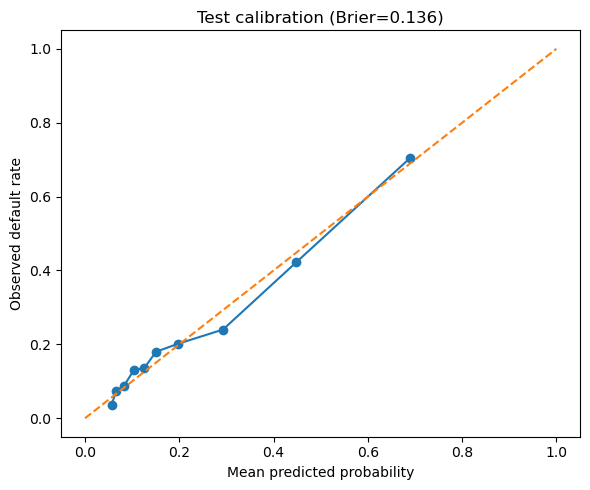

In [42]:
prob_true,prob_pred=calibration_curve(y_test,p_test,n_bins=10,strategy='quantile')
plt.figure(figsize=(6,5));
plt.plot(prob_pred,prob_true,marker='o');
plt.plot([0,1],[0,1],linestyle='--');
plt.xlabel('Mean predicted probability');
plt.ylabel('Observed default rate');
plt.title(f'Test calibration (Brier={test_metrics["Brier"]:.3f})');
plt.tight_layout();
plt.show()

## 18. Test confusion matrix

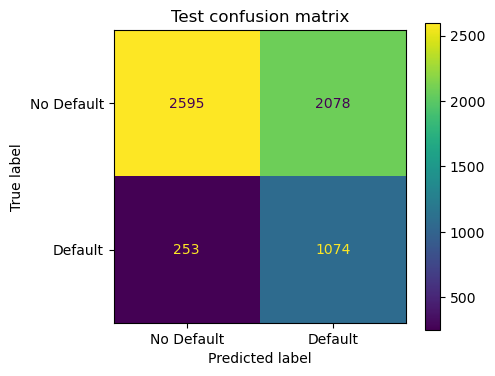

Confusion matrix:
 [[2595 2078]
 [ 253 1074]]

Default precision: 0.34073604060913704
Default recall: 0.8093443858327054
Default F1: 0.4795713328868051
Macro F1: 0.5848195715092183


In [43]:
cm=confusion_matrix(y_test,y_test_pred,labels=[0,1])
fig,ax=plt.subplots(figsize=(5,4)); ConfusionMatrixDisplay(cm,display_labels=['No Default','Default']).plot(ax=ax);
ax.set_title('Test confusion matrix');
plt.tight_layout();
plt.show()
print('Confusion matrix:\n',cm)
print('\nDefault precision:',precision_score(y_test,y_test_pred))
print('Default recall:',recall_score(y_test,y_test_pred))
print('Default F1:',f1_score(y_test,y_test_pred))
print('Macro F1:',f1_score(y_test,y_test_pred,average='macro'))

In [44]:
audit_test=X_test.copy()
audit_test['target']=y_test.values
audit_test['pred']=y_test_pred
audit_test['prob']=p_test

groups=[]
for value,g in audit_test.groupby('SEX'):
    groups.append({'group':f'SEX={value}','n':len(g),'default_rate':g['target'].mean(),'precision':precision_score(g['target'],g['pred'],zero_division=0),'recall':recall_score(g['target'],g['pred'],zero_division=0),'brier':brier_score_loss(g['target'],g['prob'])})

audit_test['AGE_GROUP']=pd.cut(audit_test['AGE'],bins=[20,25,30,35,40,50,60,100],labels=['20-24','25-29','30-34','35-39','40-49','50-59','60+'],right=False)
for value,g in audit_test.groupby('AGE_GROUP',observed=True):
    groups.append({'group':str(value),'n':len(g),'default_rate':g['target'].mean(),'precision':precision_score(g['target'],g['pred'],zero_division=0),'recall':recall_score(g['target'],g['pred'],zero_division=0),'brier':brier_score_loss(g['target'],g['prob'])})
subgroup_df=pd.DataFrame(groups)
subgroup_df

,group,n,default_rate,precision,recall,brier
0,SEX=1,2402,0.233555,0.347305,0.827094,0.143615
1,SEX=2,3598,0.212896,0.335903,0.796345,0.131197
2,20-24,541,0.253235,0.328729,0.868613,0.145902
3,25-29,1371,0.211524,0.337261,0.789655,0.132623
4,30-34,1147,0.189189,0.311031,0.792627,0.122812
5,35-39,1051,0.224548,0.371648,0.822034,0.138104
6,40-49,1341,0.232662,0.353276,0.794872,0.141722
7,50-59,473,0.236786,0.326389,0.839286,0.141202
8,60+,76,0.302632,0.391304,0.782609,0.176280


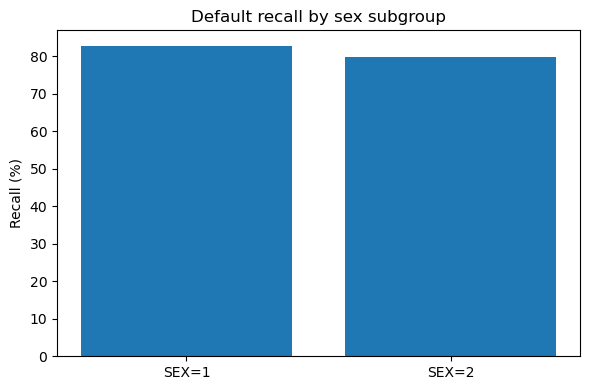

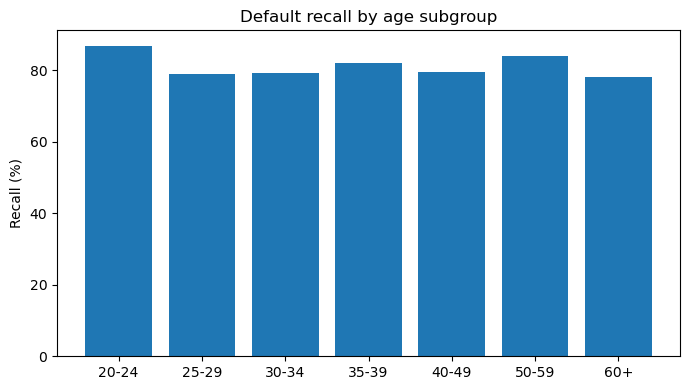

In [45]:
sex_df=subgroup_df[subgroup_df['group'].str.startswith('SEX=')]
plt.figure(figsize=(6,4));
plt.bar(sex_df['group'],sex_df['recall']*100);
plt.ylabel('Recall (%)');
plt.title('Default recall by sex subgroup');
plt.tight_layout();
plt.show()

age_df=subgroup_df[~subgroup_df['group'].str.startswith('SEX=')]
plt.figure(figsize=(7,4));
plt.bar(age_df['group'],age_df['recall']*100);
plt.ylabel('Recall (%)');
plt.title('Default recall by age subgroup');
plt.tight_layout();
plt.show()

## 20. Final experiment summary and exports

In [46]:
results_rows=[]
for r in model_rows:
    results_rows.append({'experiment':'baseline_'+r['model'],'family':r['model'],'feature_count':len(model_features),'validation_ap':r['validation_ap'],'validation_roc_auc':r['validation_roc_auc'],'validation_brier':r['validation_brier'],'runtime_sec':r['runtime_sec']})
for r in robust_rows:
    results_rows.append({'experiment':'robust_'+r['preprocessing'],'family':'Random Forest','feature_count':len(model_features),'validation_ap':r['validation_ap'],'validation_roc_auc':np.nan,'validation_brier':r['validation_brier'],'runtime_sec':r['runtime_sec']})
for _,r in comparison_df.iterrows():
    results_rows.append({'experiment':'GA_comparison_'+str(r['model']),'family':'Random Forest','feature_count':int(r['n_features']),'validation_ap':r['validation_ap'],'validation_roc_auc':r['validation_roc_auc'],'validation_brier':r['validation_brier'],'runtime_sec':r['runtime_sec']})
for _,r in ga_summary.iterrows():
    results_rows.append({'experiment':f"GA_{r['scenario']}_seed_{int(r['seed'])}",'family':'Genetic Algorithm + Logistic Regression','feature_count':int(r['n_features']),'validation_ap':r['validation_ap'],'validation_roc_auc':np.nan,'validation_brier':np.nan,'runtime_sec':r['runtime_sec']})
results_rows.append({'experiment':'tuned_calibrated_rf','family':'Random Forest + calibration','feature_count':len(model_features),'validation_ap':average_precision_score(y_val,p_val_cal),'validation_roc_auc':roc_auc_score(y_val,p_val_cal),'validation_brier':brier_score_loss(y_val,p_val_cal),'runtime_sec':search_runtime+final_calibration_runtime,'test_ap':test_metrics['AUC_PR'],'test_roc_auc':test_metrics['ROC_AUC'],'test_recall':test_metrics['Recall_default'],'test_precision':test_metrics['Precision_default'],'test_f1':test_metrics['F1_default'],'test_macro_f1':test_metrics['Macro_F1'],'test_brier':test_metrics['Brier'],'test_cost':test_metrics['Cost'],'threshold':best_threshold,'test_review_rate':test_metrics['Review_rate']})
results_df=pd.DataFrame(results_rows)
display(results_df)
print('\nFinal test metrics:')
display(pd.Series(test_metrics))

OUTPUT_DIR=Path('outputs')
OUTPUT_DIR.mkdir(exist_ok=True)
descriptive_stats.to_csv(OUTPUT_DIR/'descriptive_stats.csv',index=False)
train_outlier_thresholds.to_csv(OUTPUT_DIR/'train_outlier_thresholds.csv',index=False)
classwise_comparison.to_csv(OUTPUT_DIR/'classwise_preprocessing_comparison.csv',index=False)
model_comparison.to_csv(OUTPUT_DIR/'baseline_comparison.csv',index=False)
robust_comparison.to_csv(OUTPUT_DIR/'robust_comparison.csv',index=False)
th_df.to_csv(OUTPUT_DIR/'threshold_search_validation.csv',index=False)
threshold_cal_df.to_csv(OUTPUT_DIR/'threshold_search_calibrated_validation.csv',index=False)
operational_threshold_df.to_csv(OUTPUT_DIR/'operational_threshold_comparison.csv',index=False)
ga_summary.to_csv(OUTPUT_DIR/'ga_summary.csv',index=False)
stability.to_csv(OUTPUT_DIR/'ga_stability.csv',index=False)
comparison_df.to_csv(OUTPUT_DIR/'ga_feature_comparison.csv',index=False)
sensitivity_df.to_csv(OUTPUT_DIR/'noise_sensitivity.csv',index=False)
subgroup_df.to_csv(OUTPUT_DIR/'subgroup_audit.csv',index=False)
results_df.to_csv(OUTPUT_DIR/'results.csv',index=False)
pd.DataFrame([test_metrics]).to_csv(OUTPUT_DIR/'final_test_metrics.csv',index=False)
pd.DataFrame([{'split':'Train pool','n':len(X_train),'share':len(X_train)/len(X),'default_rate':y_train.mean()}, {'split':'Test','n':len(X_test),'share':len(X_test)/len(X),'default_rate':y_test.mean()}]).to_csv(OUTPUT_DIR/'split_audit.csv',index=False)
print('Saved experiment tables to:',OUTPUT_DIR.resolve())

,experiment,family,feature_count,validation_ap,validation_roc_auc,validation_brier,runtime_sec,test_ap,test_roc_auc,test_recall,test_precision,test_f1,test_macro_f1,test_brier,test_cost,threshold,test_review_rate
0,baseline_Dummy,Dummy,28,0.221167,0.500000,0.172252,0.065042,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,baseline_Logistic Regression,Logistic Regression,28,0.538239,0.767714,0.182553,0.182904,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,baseline_Random Forest,Random Forest,28,0.551494,0.781142,0.174419,0.338184,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,robust_standard,Random Forest,28,0.552571,NaN,0.176131,0.196935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,robust_robust,Random Forest,28,0.546565,NaN,0.176238,0.207151,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,robust_yeojohnson_robust,Random Forest,28,0.546833,NaN,0.176210,0.404654,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,GA_comparison_All features,Random Forest,28,0.551494,0.781142,0.174419,0.356545,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,GA_comparison_GA with sensitive,Random Forest,8,0.538986,0.767643,0.183026,0.178833,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,GA_comparison_GA without sensitive,Random Forest,10,0.537167,0.766894,0.181311,0.195019,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,GA_with_sensitive_seed_11,Genetic Algorithm + Logistic Regression,14,0.536972,NaN,NaN,7.504862,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN



Final test metrics:


AUC_PR                  0.550526
ROC_AUC                 0.778058
Precision_default       0.340736
Recall_default          0.809344
F1_default              0.479571
Macro_F1                0.584820
Brier                   0.136168
TN                   2595.000000
FP                   2078.000000
FN                    253.000000
TP                   1074.000000
Cost                 3343.000000
Review_rate             0.525333
Threshold               0.130000
dtype: float64

Saved experiment tables to: C:\Users\asadi\Desktop\Credit_Default\Credit_Default\outputs
